In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np


In [ ]:
#Loading the dataset water_potability.csv with pandas
df = pd.read_csv('/content/drive/MyDrive/untitled folder/Untitled Folder/water_potability.csv')

In [ ]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.080795,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,333.775777,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,333.775777,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
np.shape(df)

(6552, 10)

In [ ]:
print('Number of null values in different columns are: ')
print('--------------------------------------------------')
print(df.isna().sum())
print('--------------------------------------------------')

Number of null values in different columns are: 
--------------------------------------------------
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64
--------------------------------------------------


In [ ]:
#df = df.dropna()
#ph_mean = df.mean(axis=0)
#print(ph_mean)
#df = df.assign(ph = ph_mean, Sulfate = ph_mean, Trihalomethanes = ph_mean)
#print(df.isna().sum())

In [ ]:
np.shape(df)

(6552, 10)

In [ ]:
print('Number of null values in different columns are: ')
print('--------------------------------------------------')
print(df.isna().sum())
print('--------------------------------------------------')

Number of null values in different columns are: 
--------------------------------------------------
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64
--------------------------------------------------


In [ ]:
df1 = df
df1.add(df,1)
np.shape(df1)

(6552, 10)

In [ ]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000,6552.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.469844,32.877252,8767.901548,1.582964,36.139854,80.817895,3.307909,15.768678,0.780323,0.487812
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690300,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.080795,196.967627,20927.833605,7.130299,333.775777,421.884968,14.218338,66.396293,3.955028,0.000000
75%,7.870050,216.667456,27332.762125,8.114887,350.385756,481.792305,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df.reset_index(inplace=True)
df = df.drop(['index'],axis=1)

In [ ]:
df.groupby("Potability").count()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
Potability,,,,,,,,,
0,3996,3996,3996,3996,3996,3996,3996,3996,3996
1,2556,2556,2556,2556,2556,2556,2556,2556,2556


In [ ]:
y = df['Potability']
X = df.drop(['Potability'],axis=1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)
print('Size Training Set: {}'.format(len(X_train)))
print('Size Testing Set: {}'.format(len(X_test)))

Size Training Set: 5241
Size Testing Set: 1311


In [ ]:
#Let's Load keras
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
#from tensorflow.keras.callbacks import EarlyStopping
#early_stopping = EarlyStopping(monitor="val_loss",
                               #mode = 'auto',
                              # patience=15)

In [ ]:
# defining model
model = keras.Sequential()
model.add(layers.Dense(25, activation='relu', input_dim=9))
model.add(layers.Dense(20, activation='relu'))
model.add(layers.Dense(20, activation='relu'))
model.add(layers.Dense(1))

In [ ]:
opt = keras.optimizers.Adam()

model.compile(loss='mean_squared_error', optimizer=opt,metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, batch_size=32, epochs=200, validation_data=(X_test, y_test))

Epoch 1/200
164/164 [==============================] - 2s 4ms/step - loss: 0.2482 - accuracy: 0.5947 - val_loss: 0.2352 - val_accuracy: 0.6171
Epoch 2/200
164/164 [==============================] - 0s 2ms/step - loss: 0.2365 - accuracy: 0.6108 - val_loss: 0.2362 - val_accuracy: 0.6217
Epoch 3/200
164/164 [==============================] - 0s 2ms/step - loss: 0.2339 - accuracy: 0.6138 - val_loss: 0.2279 - val_accuracy: 0.6224
Epoch 4/200
164/164 [==============================] - 0s 2ms/step - loss: 0.2316 - accuracy: 0.6146 - val_loss: 0.2271 - val_accuracy: 0.6407
Epoch 5/200
164/164 [==============================] - 0s 2ms/step - loss: 0.2309 - accuracy: 0.6226 - val_loss: 0.2238 - val_accuracy: 0.6468
Epoch 6/200
164/164 [==============================] - 0s 2ms/step - loss: 0.2279 - accuracy: 0.6260 - val_loss: 0.2254 - val_accuracy: 0.6453
Epoch 7/200
164/164 [==============================] - 0s 2ms/step - loss: 0.2264 - accuracy: 0.6319 - val_loss: 0.2214 - val_accuracy: 0.6575

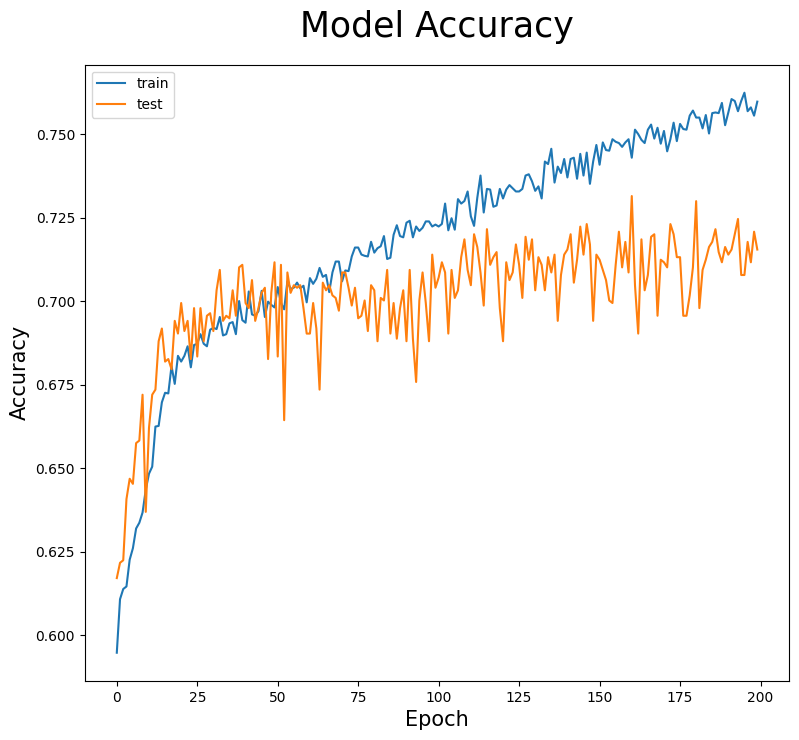

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=[20,8])

# summarize history for accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy', size=25, pad=20)
plt.ylabel('Accuracy', size=15)
plt.xlabel('Epoch', size=15)
plt.legend(['train', 'test'], loc='upper left')

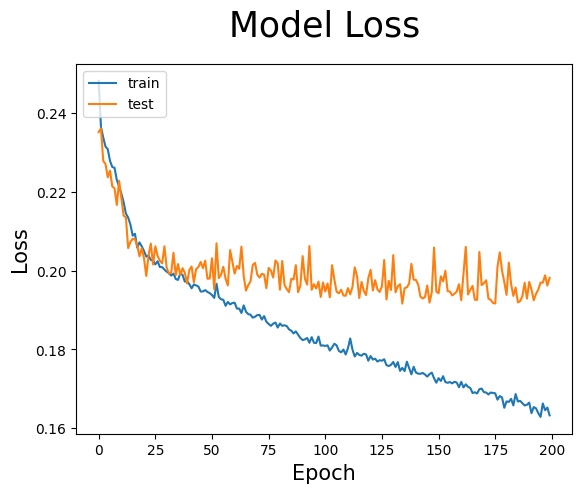

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss', size=25, pad=20)
plt.ylabel('Loss', size=15)
plt.xlabel('Epoch', size=15)
plt.legend(['train', 'test'], loc='upper left')

In [ ]:
from sklearn.metrics import roc_curve
y_pred_keras = model.predict(X_test).ravel()
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)


41/41 [==============================] - 0s 2ms/step


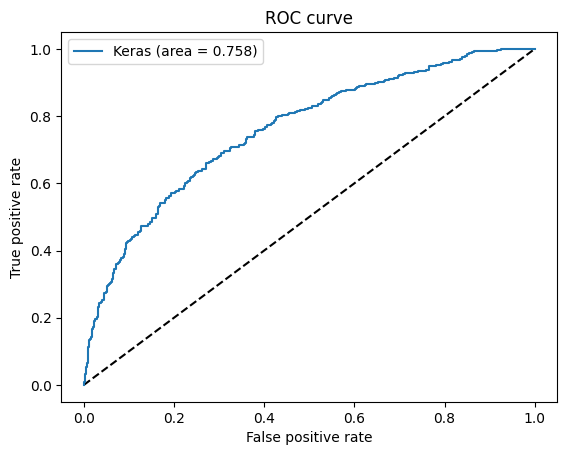

In [ ]:
from sklearn.metrics import auc
auc_keras = auc(fpr_keras, tpr_keras)
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='Keras (area = {:.3f})'.format(auc_keras))
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.legend(loc='best')
plt.show()

In [ ]:
y_pred = model.predict(X_test)
y_pred = y_pred > 0.5
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

41/41 [==============================] - 0s 3ms/step


Text(0.5, 23.52222222222222, 'Predicted label')

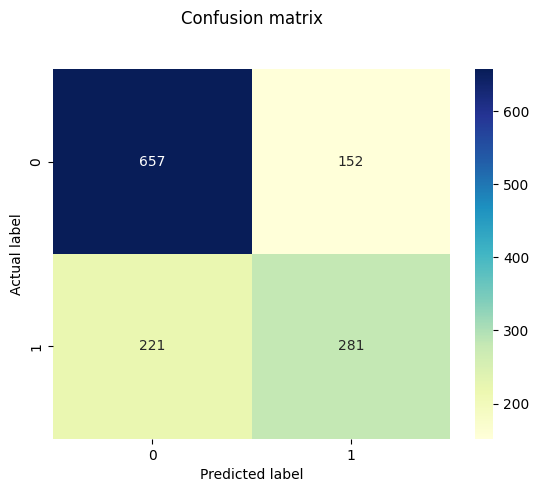

In [ ]:
import seaborn as sns
p = sns.heatmap(pd.DataFrame(cm), annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')